# 4. Deep Learning Comparison (PyTorch)

Tests whether the paper's pragmatic choice of XGBoost costs meaningful accuracy against deep learning alternatives. Three PyTorch architectures are trained and evaluated on the identical held-out split used throughout this project:

- **MLP** -- a feedforward net on the exact same full engineered feature vector used by XGBoost/ridge, isolating whether a neural net's nonlinearity helps over a tree ensemble on identical inputs.
- **LSTM** and **1-D CNN** -- consume raw 8-step (2-hour) sequences of the current-timestep base variables (no hand-engineered lag/rolling columns), testing whether a learned temporal representation can substitute for that feature engineering.

This notebook requires PyTorch: `pip install -r requirements-torch.txt` (not part of the core `requirements.txt` -- the deployed edge pipeline never needs it).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from evloadshaping.data import load_raw_data
from evloadshaping.features import build_features, split_data
from evloadshaping.models import compute_baselines, evaluate_model, train_model
from evloadshaping.torch_models import run_torch_comparison

DATA_PATH = Path('../data/20260514_uma_adabyron_data.csv')

## Load, engineer features, and split

Same chronological 80/20 split used throughout the project.

In [2]:
raw_frame, charger_ids = load_raw_data(DATA_PATH)
feature_frame = build_features(raw_frame, charger_ids)
x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test = split_data(feature_frame)
print(f'Train: {len(x_train):,} rows | Test: {len(x_test):,} rows')

Train: 46,144 rows | Test: 11,537 rows


## Re-establish the non-deep-learning baselines

Persistence, ridge, and XGBoost, exactly as in notebook 2 -- needed here again so the comparison table below is self-contained.

In [3]:
model_pv = train_model(x_train, y_pv_train)
model_ev = train_model(x_train, y_ev_train)
pv_metrics = evaluate_model(y_pv_test, model_pv.predict(x_test))
ev_metrics = evaluate_model(y_ev_test, model_ev.predict(x_test))

baselines = compute_baselines(x_test, y_pv_test, y_ev_test, x_train, y_pv_train, y_ev_train)

## Train and evaluate the three PyTorch architectures

This is the slow cell -- training six small networks (3 architectures × 2 targets) with early stopping. A few minutes on CPU, faster with an MPS/CUDA device.

In [4]:
torch_results = run_torch_comparison(x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test)
torch_results

{'mlp': {'pv': {'mae': 494.10430801623625, 'rmse': 960.251865292769},
  'ev': {'mae': 77.18204368688363, 'rmse': 272.83411601000546}},
 'lstm': {'pv': {'mae': 488.7045593261719, 'rmse': 974.0048447004768},
  'ev': {'mae': 76.0069808959961, 'rmse': 269.46861772291777}},
 'cnn': {'pv': {'mae': 539.8751220703125, 'rmse': 1014.8838295588318},
  'ev': {'mae': 92.33650207519531, 'rmse': 285.3152450579884}}}

## Full comparison table

In [5]:
rows = [
    {'model': 'persistence', 'target': 'pv', **baselines['persistence']['pv']},
    {'model': 'ridge_regression', 'target': 'pv', **baselines['ridge_regression']['pv']},
    {'model': 'xgboost', 'target': 'pv', **pv_metrics},
    {'model': 'mlp', 'target': 'pv', **torch_results['mlp']['pv']},
    {'model': 'lstm', 'target': 'pv', **torch_results['lstm']['pv']},
    {'model': 'cnn', 'target': 'pv', **torch_results['cnn']['pv']},
    {'model': 'persistence', 'target': 'ev', **baselines['persistence']['ev']},
    {'model': 'ridge_regression', 'target': 'ev', **baselines['ridge_regression']['ev']},
    {'model': 'xgboost', 'target': 'ev', **ev_metrics},
    {'model': 'mlp', 'target': 'ev', **torch_results['mlp']['ev']},
    {'model': 'lstm', 'target': 'ev', **torch_results['lstm']['ev']},
    {'model': 'cnn', 'target': 'ev', **torch_results['cnn']['ev']},
]
comparison = pd.DataFrame(rows)
comparison.round(2)

,model,target,mae,rmse
0,persistence,pv,465.35,1024.03
1,ridge_regression,pv,503.99,977.85
2,xgboost,pv,453.87,963.92
3,mlp,pv,494.10,960.25
4,lstm,pv,488.70,974.00
5,cnn,pv,539.88,1014.88
6,persistence,ev,52.29,273.24
7,ridge_regression,ev,64.41,265.35
8,xgboost,ev,64.86,296.19
9,mlp,ev,77.18,272.83


## Discussion

If the tree ensemble and simple baselines still beat all three PyTorch architectures here, that is consistent with well-documented findings that gradient-boosted trees are highly competitive with (and often beat) deep learning on small-to-medium tabular datasets -- the training set here is ~46k rows, well within the regime where that pattern typically holds. It also reinforces the paper's deployment story: even setting aside the runtime-footprint argument for edge deployment (Section VII), the accuracy case for going beyond XGBoost is not there either.

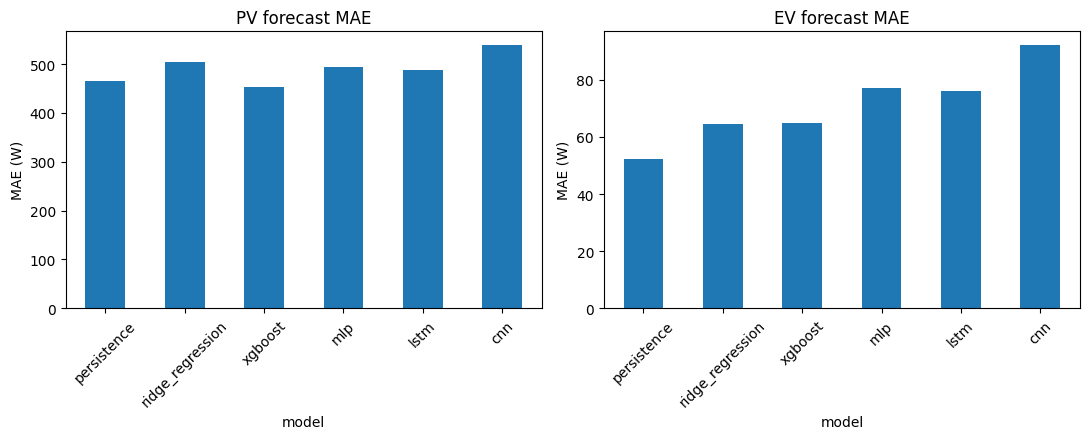

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for target, ax in zip(['pv', 'ev'], axes):
    subset = comparison[comparison['target'] == target].set_index('model')
    subset['mae'].plot.bar(ax=ax, color='tab:blue')
    ax.set_title(f'{target.upper()} forecast MAE')
    ax.set_ylabel('MAE (W)')
    ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()